# ORT: Zwaartekracht Basis

**Hoofdstuk 12, deel 1 | §12.1–12.14 | Formules 23–39**

Dit notebook behandelt de basiseffecten van zwaartekracht in de ORT.
Het kernidee: nabij massa daalt de lokale ruimtetijdsnelheid: $c_{local}(r) < c$.
Uit deze ene uitbreiding volgen gravitationele tijddilatatie, roodverschuiving,
lichtafbuiging, baanprecissie, en de volledige Schwarzschildmetriek.

---

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import *
from ort_plots import (c_local_profile, c_local_profile_interactive, spacetime_embedding_3d,
    orbital_precession_plot, light_deflection_diagram, photon_sphere_shadow, einstein_ring_plot, comparison_table)
import matplotlib.pyplot as plt
import math
import numpy as np
%matplotlib inline

## §12.1 — Het Principe: $c_{local}$ varieert nabij massa

In de SRT is de ruimtetijdsnelheid overal gelijk: $c$. Nabij massa daalt deze **lokale ruimtetijdsnelheid**:

$$c_{local}(r) = c \cdot \sqrt{1 - \frac{r_s}{r}} \qquad (23)$$

waarbij de **Schwarzschildstraal** gegeven wordt door:

$$r_s = \frac{2GM}{c^2}$$

Het kernidee: **nabij energie/massa daalt de lokale ruimtetijdsnelheid**.
- Ver van massa: $c_{local} \to c$ (vlakke ruimtetijd)
- Op de eventhorizon ($r = r_s$): $c_{local} = 0$ (alles stopt)

Hetzelfde patroon als bij de SRT:
- **SRT**: constante $c$ → tijddilatatie, lengtecontractie, $E = mc^2$
- **Zwaartekracht**: variërende $c_{local}$ → gravitationele tijddilatatie, roodverschuiving, eventhorizon

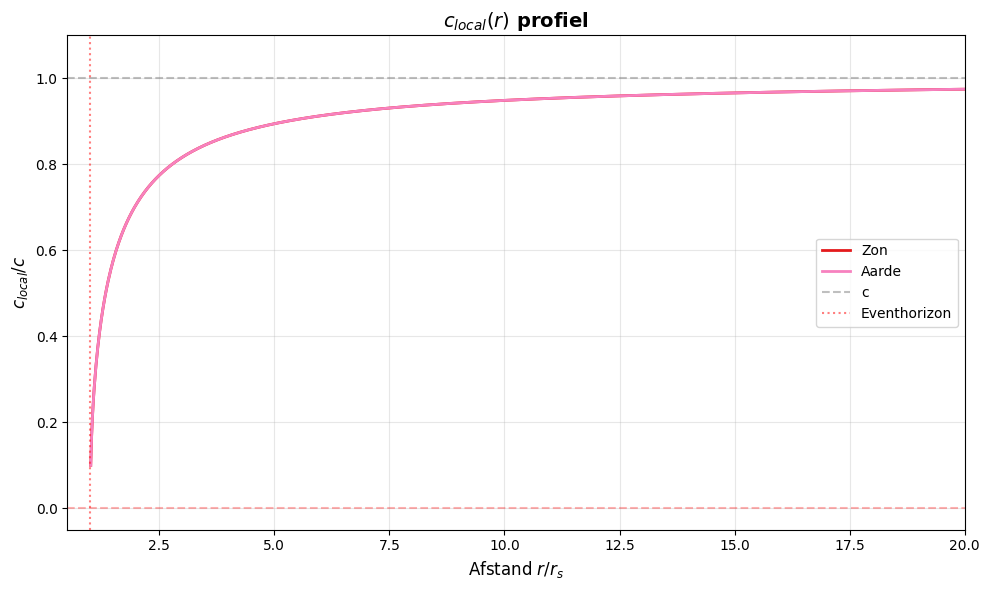

In [2]:
# c_local profiel voor de Zon en de Aarde
fig = c_local_profile([SUN, EARTH], ['Zon', 'Aarde'], lang='nl')
plt.show()

In [3]:
# Interactief: pas de massa aan en bekijk het c_local-profiel
c_local_profile_interactive(lang='nl')

interactive(children=(FloatSlider(value=30.0, description='log₁₀(M/kg)', max=40.0, min=24.0, step=0.5), Output…

## §12.2 — Gravitationele tijddilatatie

Een klok op afstand $r$ van een massa ervaart $c_{local} < c$. Als de klok stilstaat gaat alle $c_{local}$ naar beweging door de tijd:

$$\frac{\tau}{t_\infty} = \frac{c_{local}}{c} = \sqrt{1 - \frac{r_s}{r}} \qquad (24/25)$$

Dit is **exact** de Schwarzschild-tijddilatatie uit de ART.

In [4]:
# Tijddilatatie op het aardoppervlak, GPS-hoogte, ISS-hoogte
print("=== Gravitationele tijddilatatie (Aarde) ===")
print(f"Schwarzschildstraal Aarde: r_s = {EARTH.rs:.4e} m = {EARTH.rs*1000:.4f} mm")
print()

locations = [
    ("Aardoppervlak", R_EARTH),
    ("ISS (408 km)", R_ISS),
    ("GPS (20.200 km)", R_GPS),
]
for name, r in locations:
    td = EARTH.time_dilation_factor(r)
    diff_per_day = (1 - td) * 86400e6  # microseconden per dag
    print(f"{name:25s}: τ/t∞ = {td:.15f}  (verschil: {diff_per_day:.3f} µs/dag)")

=== Gravitationele tijddilatatie (Aarde) ===
Schwarzschildstraal Aarde: r_s = 8.8698e-03 m = 8.8698 mm

Aardoppervlak            : τ/t∞ = 0.999999999303892  (verschil: 60.144 µs/dag)
ISS (408 km)             : τ/t∞ = 0.999999999345788  (verschil: 56.524 µs/dag)
GPS (20.200 km)          : τ/t∞ = 0.999999999833092  (verschil: 14.421 µs/dag)


In [5]:
# Newton vs ORT: tijddilatatie op GPS-hoogte
# Newton kent GEEN tijddilatatie — tijd is absoluut!
r_gps = R_EARTH + 20_200_000  # GPS-hoogte ~20.200 km
td_ort = EARTH.time_dilation_factor(r_gps)
drift_per_day_us = (1 - td_ort) * 86400 * 1e6  # µs per dag

print("=== Newton vs ORT: gravitationele tijddilatatie ===")
print(f"Klok op GPS-hoogte ({20200} km):")
print(f"  Newton:  Δt = 0 µs/dag      (tijd is absoluut!)")
print(f"  ORT:     Δt = {drift_per_day_us:+.2f} µs/dag  (klok loopt SNELLER)")
print()
print(f"Zonder correctie: GPS zou na 1 dag {abs(drift_per_day_us) * C * 1e-6:.0f} m afwijken!")
print(f"Na 1 week: {abs(drift_per_day_us) * 7 * C * 1e-6:.0f} m — navigatie onbruikbaar.")

=== Newton vs ORT: gravitationele tijddilatatie ===
Klok op GPS-hoogte (20200 km):
  Newton:  Δt = 0 µs/dag      (tijd is absoluut!)
  ORT:     Δt = +14.42 µs/dag  (klok loopt SNELLER)

Zonder correctie: GPS zou na 1 dag 4323 m afwijken!
Na 1 week: 30263 m — navigatie onbruikbaar.


## §12.3 — Gravitationele roodverschuiving

Licht dat ontsnapt uit een zwaartekrachtsveld verliest frequentie:

$$\frac{f_{obs}}{f_{emit}} = \frac{c_{local}(r_{emit})}{c_{local}(r_{obs})} = \frac{\sqrt{1 - r_s/r_{emit}}}{\sqrt{1 - r_s/r_{obs}}} \qquad (25/27)$$

Als de waarnemer verder van de massa staat: $f_{obs} < f_{emit}$ → **roodverschuiving**.

In [6]:
# Pound-Rebka experiment (1959): 22.5 m hoogteverschil
h = 22.5  # meter
r_bottom = R_EARTH
r_top = R_EARTH + h

z = EARTH.gravitational_redshift(r_bottom, r_top)
delta_f_over_f = -z  # roodverschuiving = negatief

# Benadering: Δf/f ≈ g·h/c²
g = G * M_EARTH / R_EARTH**2
approx = g * h / C**2

print("=== Pound-Rebka experiment ===")
print(f"Hoogte: {h} m")
print(f"Roodverschuiving z     = {z:.6e}")
print(f"|Δf/f|                 = {abs(delta_f_over_f):.6e}")
print(f"Benadering g·h/c²      = {approx:.6e}")
print(f"Gemeten (1959)         = (2.57 ± 0.26) × 10⁻¹⁵")

=== Pound-Rebka experiment ===
Hoogte: 22.5 m
Roodverschuiving z     = 2.442491e-15
|Δf/f|                 = 2.442491e-15
Benadering g·h/c²      = 2.458394e-15
Gemeten (1959)         = (2.57 ± 0.26) × 10⁻¹⁵


## §12.4 — GPS volledige correctie (SRT + zwaartekracht)

GPS combineert **beide** effecten in één formule:

$$v_{tijd} = \frac{\sqrt{c_{local}^2 - v^2}}{c} \qquad (26)$$

| Component | Oorzaak | Effect |
|-----------|---------|--------|
| SRT | Snelheid satelliet (3870 m/s) | −7 µs/dag (langzamer) |
| Zwaartekracht | Lagere g op GPS-hoogte | +45 µs/dag (sneller) |
| **Netto** | **Combinatie** | **+38 µs/dag (sneller)** |

In [7]:
# GPS correctie: combinatie SRT + zwaartekracht
v_gps = 3870  # m/s (GPS satelliet snelheid)

# Aardoppervlak (in rust)
td_surface = EARTH.combined_time_dilation(R_EARTH, 0)

# GPS satelliet (bewegend op hoogte)
td_gps = EARTH.combined_time_dilation(R_GPS, v_gps)

# Verschil in microseconden per dag
diff_us_per_day = (td_gps - td_surface) * 86400 * 1e6

# Afzonderlijke componenten
grav_only = (EARTH.time_dilation_factor(R_GPS) - EARTH.time_dilation_factor(R_EARTH)) * 86400 * 1e6
srt_only = (math.sqrt(1 - (v_gps/C)**2) - 1) * 86400 * 1e6

print("=== GPS Correctie ===")
print(f"Alleen zwaartekracht:   {grav_only:+.2f} µs/dag")
print(f"Alleen SRT (snelheid):  {srt_only:+.2f} µs/dag")
print(f"Gecombineerd (formule): {diff_us_per_day:+.2f} µs/dag")
print(f"\nVerwacht netto:         +38 µs/dag")

=== GPS Correctie ===
Alleen zwaartekracht:   +45.72 µs/dag
Alleen SRT (snelheid):  -7.20 µs/dag
Gecombineerd (formule): +38.52 µs/dag

Verwacht netto:         +38 µs/dag


## §12.5 — De eventhorizon ($c_{local} = 0$)

Bij $r = r_s$ wordt $c_{local} = 0$. De consequenties:

1. **Niets kan bewegen** — niet door de ruimte, niet door de tijd
2. **Klokken staan stil** — $\tau/t_\infty = 0$
3. **Licht kan niet ontsnappen** — er is geen lokale ruimtetijdsnelheid meer

In [8]:
# Zwart gat van 10 zonsmassa's
BH_10 = GravityModel(10 * M_SUN)
print(f"=== Zwart gat van 10 M☉ ===")
print(f"r_s = {BH_10.rs:.3e} m = {BH_10.rs/1000:.2f} km")
print()

# c_local op verschillende afstanden van de horizon
factors = [10.0, 5.0, 2.0, 1.5, 1.1, 1.01, 1.001, 1.0]
print(f"{'r/r_s':>8s}  {'c_local/c':>12s}  {'c_local (m/s)':>15s}")
print("-" * 40)
for f in factors:
    r = f * BH_10.rs
    cl = BH_10.c_local(r)
    print(f"{f:8.3f}  {cl/C:12.6f}  {cl:15.0f}")

=== Zwart gat van 10 M☉ ===
r_s = 2.954e+04 m = 29.54 km

   r/r_s     c_local/c    c_local (m/s)
----------------------------------------
  10.000      0.948683        284408098
   5.000      0.894427        268142526
   2.000      0.707107        211985280
   1.500      0.577350        173085256
   1.100      0.301511         90390827
   1.010      0.099504         29830465
   1.001      0.031607          9475533
   1.000      0.000000                0


## §12.6 — De gravitatiesnelheid $v_{grav}$

Nabij een massa gaat een deel van je totale snelheid $c$ **richting die massa**:

$$v_{grav}^2 + c_{local}^2 = c^2 \qquad (27)$$

$$v_{grav} = c \cdot \sqrt{\frac{r_s}{r}} \qquad (28)$$

Dit is **exact** de ontsnappingssnelheid $v_{esc} = \sqrt{2GM/r}$.

Voor een bewegend object geldt het **driecomponenten-budget**:

$$v_{grav}^2 + v_{ruimte}^2 + v_{tijd}^2 = c^2 \qquad (29)$$

In [9]:
# v_grav op verschillende afstanden
print("=== Snelheidsbudget nabij 10 M☉ zwart gat ===")
print(f"{'r/r_s':>8s}  {'v_grav/c':>10s}  {'c_local/c':>10s}  {'check v²+c²':>12s}")
print("-" * 46)
for f in [10.0, 5.0, 2.0, 1.5, 1.1, 1.01, 1.0]:
    r = f * BH_10.rs
    vg = BH_10.v_grav(r)
    cl = BH_10.c_local(r)
    check = math.sqrt(vg**2 + cl**2) / C
    print(f"{f:8.3f}  {vg/C:10.6f}  {cl/C:10.6f}  {check:12.9f}")

=== Snelheidsbudget nabij 10 M☉ zwart gat ===
   r/r_s    v_grav/c   c_local/c   check v²+c²
----------------------------------------------
  10.000    0.316228    0.948683   1.000000000
   5.000    0.447214    0.894427   1.000000000
   2.000    0.707107    0.707107   1.000000000
   1.500    0.816497    0.577350   1.000000000
   1.100    0.953463    0.301511   1.000000000
   1.010    0.995037    0.099504   1.000000000
   1.000    1.000000    0.000000   1.000000000


## §12.7 — Ruimtelijke uitrekking

Een coördinaatafstand $dr$ correspondeert met een grotere fysieke afstand $dl$:

$$dl = \frac{dr}{\sqrt{1 - r_s/r}} = dr \cdot \frac{c}{c_{local}} \qquad (30)$$

Dit **is** de ruimtelijke component van de Schwarzschildmetriek:

$$g_{rr} = \left(1 - \frac{r_s}{r}\right)^{-1} = \left(\frac{c}{c_{local}}\right)^2$$

Samen met $g_{tt} = (c_{local}/c)^2$ matcht de ORT nu **beide** diagonaalcomponenten.

In [10]:
# Ruimtelijke uitrekking nabij de Zon en een 10 M☉ zwart gat
print("=== Ruimtelijke uitrekking ===")
print()
print("--- Zon (oppervlak) ---")
stretch_sun = SUN.spatial_stretching(R_SUN)
print(f"Uitrekkingsfactor: {stretch_sun:.10f}")
print(f"Extra lengte per km: {(stretch_sun - 1) * 1000:.6f} m")
print()
print("--- 10 M☉ zwart gat ---")
for f in [10.0, 3.0, 1.5, 1.1, 1.01]:
    r = f * BH_10.rs
    s = BH_10.spatial_stretching(r)
    print(f"  r = {f:.2f} r_s:  uitrekking = {s:.6f}  (1 km → {s:.6f} km)")

=== Ruimtelijke uitrekking ===

--- Zon (oppervlak) ---
Uitrekkingsfactor: 1.0000021231
Extra lengte per km: 0.002123 m

--- 10 M☉ zwart gat ---
  r = 10.00 r_s:  uitrekking = 1.054093  (1 km → 1.054093 km)
  r = 3.00 r_s:  uitrekking = 1.224745  (1 km → 1.224745 km)
  r = 1.50 r_s:  uitrekking = 1.732051  (1 km → 1.732051 km)
  r = 1.10 r_s:  uitrekking = 3.316625  (1 km → 3.316625 km)
  r = 1.01 r_s:  uitrekking = 10.049876  (1 km → 10.049876 km)


## 3D Flamm-paraboloïde

De ruimtelijke uitrekking kan gevisualiseerd worden als het **Flamm-paraboloïde**: een 2D inbedding van de ruimtelijke geometrie rond een massa.

In [11]:
# 3D inbedding van de ruimtelijke geometrie
fig = spacetime_embedding_3d(lang='nl')
if fig is not None:
    fig.show()

## §12.8 — Lichtafbuiging

Licht dat langs een massa scheert wordt afgebogen door **twee gelijke bijdragen**:

1. **Temporeel** (brekingsindex): $n_{tijd} = c/c_{local}$
2. **Ruimtelijk** (uitrekking): $n_{ruimte} = c/c_{local}$

Gecombineerd: de effectieve brekingsindex:

$$n_{eff} = \left(\frac{c}{c_{local}}\right)^2 = \frac{1}{1 - r_s/r} \qquad (31)$$

De totale afbuighoek:

$$\alpha = \frac{2r_s}{b} = \frac{4GM}{bc^2} \qquad (32)$$

Dit is **exact** het resultaat van de ART (Einstein 1915: 1.75").
Soldner (1801) en Einstein (1911) vonden de **helft**: alleen het temporele effect.

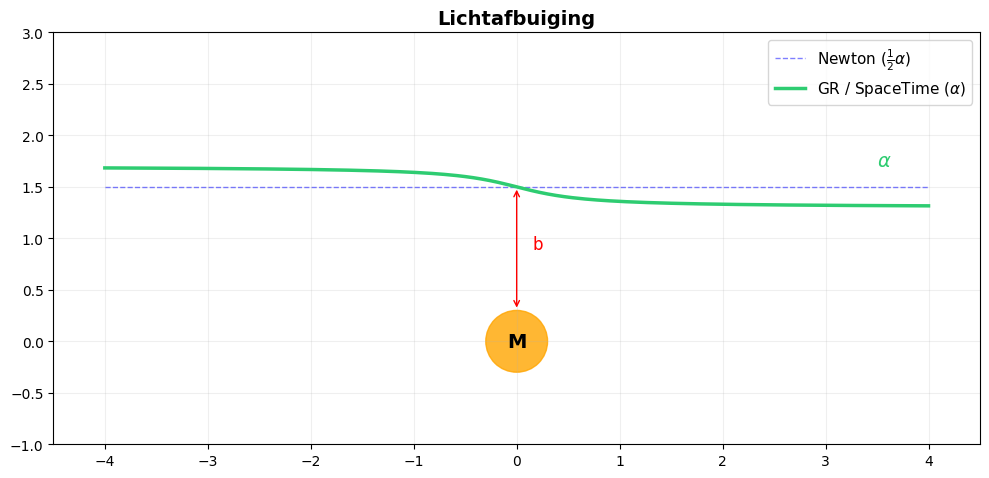

In [12]:
# Lichtafbuiging diagram
fig = light_deflection_diagram(lang='nl')
plt.show()

In [13]:
# Lichtafbuiging door de Zon (b = R_zon)
alpha_arcsec = SUN.light_deflection_arcsec(R_SUN)
alpha_half = SUN.half_light_deflection(R_SUN) * (180/math.pi) * 3600

print("=== Lichtafbuiging door de Zon ===")
print(f"Impactparameter b = R_zon = {R_SUN:.3e} m")
print(f"Soldner/Einstein 1911 (halve waarde): {alpha_half:.4f}\"")
print(f"ORT / ART (volledige):    {alpha_arcsec:.4f}\"")
print(f"Gemeten (Eddington 1919):             1.75 ± 0.06\"")

=== Lichtafbuiging door de Zon ===
Impactparameter b = R_zon = 6.957e+08 m
Soldner/Einstein 1911 (halve waarde): 0.8759"
ORT / ART (volledige):    1.7517"
Gemeten (Eddington 1919):             1.75 ± 0.06"


In [14]:
# Newton vs ORT: lichtafbuiging door de Zon
# Newton/Soldner (1801) voorspelt de HELFT van het juiste antwoord!
alpha_newton = SUN.half_light_deflection(R_SUN) * (180 / math.pi) * 3600
alpha_ort = SUN.light_deflection_arcsec(R_SUN)

print("=== Newton vs ORT: lichtafbuiging door de Zon ===")
print(f"  Newton/Soldner (1801):  {alpha_newton:.4f}\"  (alleen tijdkromming)")
print(f"  ORT/Einstein (1915):    {alpha_ort:.4f}\"  (tijd + ruimtekromming)")
print(f"  Eddington (1919):       1.75 ± 0.06\"  (gemeten!)")
print()
print(f"Newton voorspelt exact de HELFT: {alpha_newton/alpha_ort:.3f}×")
print(f"De ontbrekende helft komt van ruimtekromming — iets dat Newton niet kent.")

=== Newton vs ORT: lichtafbuiging door de Zon ===
  Newton/Soldner (1801):  0.8759"  (alleen tijdkromming)
  ORT/Einstein (1915):    1.7517"  (tijd + ruimtekromming)
  Eddington (1919):       1.75 ± 0.06"  (gemeten!)

Newton voorspelt exact de HELFT: 0.500×
De ontbrekende helft komt van ruimtekromming — iets dat Newton niet kent.


## §12.9 — Baanprecissie

De effectieve potentiaal met GR-correctie:

$$V_{GR}(r) = -\frac{GM}{r} + \frac{L^2}{2r^2} - \frac{GML^2}{r^3 c^2} \qquad (33/34)$$

De precissie per omloop (50/50 temporeel + ruimtelijk):

$$\Delta\varphi = \frac{3\pi r_s}{a(1-e^2)} \qquad (35)$$

**Mercurius**: $\Delta\varphi = 42.98\text{"}$/eeuw — exact de waargenomen waarde.

In [15]:
# Baanprecissie van Mercurius
prec_per_orbit = SUN.orbital_precession_arcsec(A_MERCURY, E_MERCURY)
prec_per_century = SUN.orbital_precession_arcsec_century(A_MERCURY, E_MERCURY, T_MERCURY)

print("=== Baanprecissie van Mercurius ===")
print(f"Halve grote as a  = {A_MERCURY:.4e} m")
print(f"Excentriciteit e  = {E_MERCURY}")
print(f"Omlooptijd        = {T_MERCURY/86400:.3f} dagen")
print(f"\nΔφ per omloop      = {prec_per_orbit:.4f}\"")
print(f"Δφ per eeuw        = {prec_per_century:.2f}\"")
print(f"Waargenomen       = 43.0\"")

=== Baanprecissie van Mercurius ===
Halve grote as a  = 5.7909e+10 m
Excentriciteit e  = 0.20563
Omlooptijd        = 87.969 dagen

Δφ per omloop      = 0.1035"
Δφ per eeuw        = 42.99"
Waargenomen       = 43.0"


In [16]:
# Newton vs ORT: baanprecissie van Mercurius
# Newton voorspelt gesloten ellipsen — 0 extra precissie!
prec_ort = SUN.orbital_precession_arcsec(A_MERCURY, E_MERCURY)
prec_per_century = prec_ort * (100 * 365.25 * 86400) / T_MERCURY

print("=== Newton vs ORT: baanprecissie van Mercurius ===")
print(f"  Newton:           0.00\"/eeuw   (ellips sluit exact!)")
print(f"  ORT/Einstein:    {prec_per_century:.2f}\"/eeuw")
print(f"  Waargenomen:     43.0 ± 0.1\"/eeuw  (Le Verrier, 1859)")
print()
print(f"Dit onverklaarde verschil was 56 jaar lang een raadsel.")
print(f"Einstein loste het op in 1915 — zijn eerste bevestiging van de ART.")

=== Newton vs ORT: baanprecissie van Mercurius ===
  Newton:           0.00"/eeuw   (ellips sluit exact!)
  ORT/Einstein:    42.99"/eeuw
  Waargenomen:     43.0 ± 0.1"/eeuw  (Le Verrier, 1859)

Dit onverklaarde verschil was 56 jaar lang een raadsel.
Einstein loste het op in 1915 — zijn eerste bevestiging van de ART.


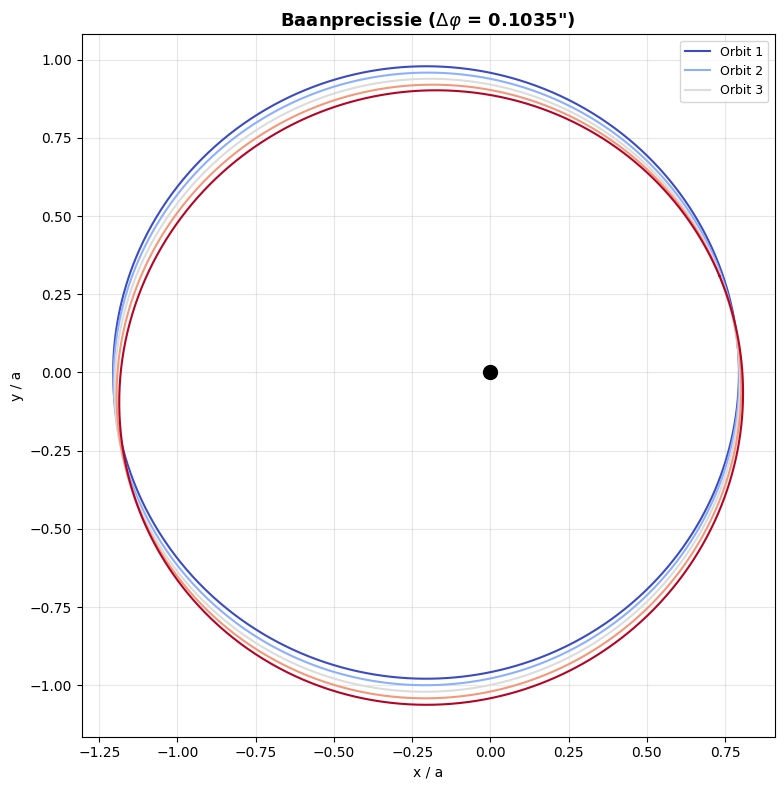

In [17]:
# Precissie-plot voor Mercurius
fig = orbital_precession_plot(SUN, A_MERCURY, E_MERCURY, n_orbits=5, lang='nl')
plt.show()

## §12.10–12.12 — De Schwarzschildverbinding

De ORT reproduceert **beide** diagonaalcomponenten van de Schwarzschildmetriek:

$$ds^2 = \underbrace{\left(1 - \frac{r_s}{r}\right)}_{g_{tt}}\, c^2 dt^2 - \underbrace{\left(1 - \frac{r_s}{r}\right)^{-1}}_{g_{rr}}\, dr^2 - r^2 d\Omega^2$$

| Component | Metriek | ORT |
|-----------|---------|------------------|
| $g_{tt}$ | $1 - r_s/r$ | $(c_{local}/c)^2$ — formule (36) |
| $g_{rr}$ | $(1 - r_s/r)^{-1}$ | $(c/c_{local})^2$ — formule (37) |

**Het patroon** (§12.12):

| Regime | Ruimtetijdsnelheid | Wat volgt |
|--------|--------------------|-----------|
| Geen massa | $c$ (constant) | SRT: tijddilatatie, $E=mc^2$, Lorentz |
| Nabij massa | $c_{local} < c$ | Gravitationele effecten |
| Eventhorizon | $c_{local} = 0$ | Niets beweegt, Zijn = 0 |

## §12.14 — Invariantie van Zijn in een zwaartekrachtsveld

In de SRT: $\text{Zijn} = m_0 \times c$. Nabij massa:

$$\text{Zijn} = m_0 \times c_{local} \qquad (38)$$

Consequenties:
- **Massa neemt NIET toe** in zwaartekracht — het is $c_{local}$ die daalt, niet $m_0$ die stijgt
- **Nabij andere zijnden daalt je Zijn** — anti-holistisch principe
- **Eventhorizon: Zijn = 0** — $c_{local} = 0 \Rightarrow m_0 \times 0 = 0$

Gravitationele bindingsenergie:

$$E_{binding} = m_0 c^2 \left(1 - \sqrt{1 - \frac{r_s}{r}}\right) \qquad (39)$$

In [18]:
# Zijn nabij de Aarde en een zwart gat
m0 = 1.0  # kg referentiemassa
print("=== Invariantie van Zijn ===")
print(f"In vlakke ruimtetijd: Zijn = m₀ × c = {m0 * C:.6e} kg·m/s")
print()

print("--- Nabij de Aarde ---")
cl_earth = EARTH.c_local(R_EARTH)
zijn_earth = m0 * cl_earth
print(f"c_local(R_aarde)  = {cl_earth:.6f} m/s")
print(f"Zijn(R_aarde)     = {zijn_earth:.6e} kg·m/s")
print(f"Zijn/Zijn_∞       = {cl_earth/C:.15f}")
print()

print("--- Nabij 10 M☉ zwart gat ---")
for f in [10.0, 2.0, 1.1, 1.01]:
    r = f * BH_10.rs
    cl = BH_10.c_local(r)
    print(f"  r = {f:.2f} r_s:  Zijn = {m0 * cl:.6e} kg·m/s  ({cl/C:.6f} c)")

print()
# Bindingsenergie
E_bind = m0 * C**2 * (1 - EARTH.time_dilation_factor(R_EARTH))
print(f"Bindingsenergie 1 kg op aardoppervlak: {E_bind:.6e} J")

=== Invariantie van Zijn ===
In vlakke ruimtetijd: Zijn = m₀ × c = 2.997925e+08 kg·m/s

--- Nabij de Aarde ---
c_local(R_aarde)  = 299792457.791312 m/s
Zijn(R_aarde)     = 2.997925e+08 kg·m/s
Zijn/Zijn_∞       = 0.999999999303892

--- Nabij 10 M☉ zwart gat ---
  r = 10.00 r_s:  Zijn = 2.844081e+08 kg·m/s  (0.948683 c)
  r = 2.00 r_s:  Zijn = 2.119853e+08 kg·m/s  (0.707107 c)
  r = 1.10 r_s:  Zijn = 9.039083e+07 kg·m/s  (0.301511 c)
  r = 1.01 r_s:  Zijn = 2.983046e+07 kg·m/s  (0.099504 c)

Bindingsenergie 1 kg op aardoppervlak: 6.256305e+07 J


---

## Samenvatting

Alle basale zwaartekrachtseffecten volgen uit één uitbreiding:

$$c_{local}(r) = c \cdot \sqrt{1 - \frac{r_s}{r}}$$

| Effect | Formule | Bevestiging |
|--------|---------|-------------|
| Tijddilatatie | $\tau/t = \sqrt{1-r_s/r}$ | GPS, atoomklokken |
| Roodverschuiving | $f_{obs}/f_{emit} = c_{local,e}/c_{local,o}$ | Pound-Rebka |
| GPS-correctie | $v_{tijd} = \sqrt{c_{local}^2 - v^2}/c$ | Dagelijkse verificatie |
| Eventhorizon | $c_{local} = 0$ bij $r = r_s$ | EHT M87*, Sgr A* |
| Lichtafbuiging | $\alpha = 4GM/(bc^2)$ | Eddington 1919 |
| Baanprecissie | $\Delta\varphi = 3\pi r_s/(a(1-e^2))$ | Mercurius 42.98"/eeuw |
| Schwarzschildmetriek | $g_{tt} = (c_{local}/c)^2$, $g_{rr} = (c/c_{local})^2$ | Exact |
| Zijn in zwaartekracht | $S = m_0 \times c_{local}$ | Behoudswet |

**Vervolg**: Notebook 03 behandelt gevorderde onderwerpen (RN, Shapiro, geodetische precessie, fotonsfeer, GW, Kerr).